In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

### Parámetros físicos

In [ ]:
w_L = 10 #frecuencia del laser del drive externo

Omega = 20        # drive del qubit

gamma = 1   #decay en el qubit
kappa = 1   #decay en la cavidad

g = 0.001            # acoplo
N = 5           # truncación del oscilador (n=0,1)


### Operadores 

In [ ]:
# Operadores en el espacio producto tensorial
SX = tensor(sigmax(), qeye(N))
SM = tensor(sigmam(), qeye(N))
SP = tensor(sigmap(), qeye(N))
SZ = tensor(sigmaz(), qeye(N))

A  = tensor(qeye(2), destroy(N))
Ad = A.dag()


# Disipadores
Dissipators = [np.sqrt(gamma)*SM, np.sqrt(kappa)*A]

### Barrido de valores $\omega_q$ y $\omega_a$

In [ ]:
# eje horizontal (frecuencia espectral)
Delta_a_list = np.linspace(-3*Omega, 3*Omega, 200)

# eje vertical (detuning del qubit)
Delta_q_list = np.linspace(-3*Omega, 3*Omega, 200)

# matriz para guardar el espectro
S_map = np.zeros((len(Delta_q_list), len(Delta_a_list)))

Hamiltoniano: $$H = \frac{\Omega}{2}\sigma_x + \Delta_a a^\dagger a +\Delta_q\sigma_z + g(a^\dagger\sigma_- + a\sigma_+)$$

Cuando la cavidad está muy debilmente acoplada, podemos calcular el espectro como $$S(\omega)\ \alpha\ \braket{a^\dagger a}^{SS}$$.


Donde $$\braket{a^\dagger a}^{SS} = Tr(\rho_{SS}a^\dagger a)$$

In [ ]:

# Doble bucle
for i, Delta_q in enumerate(Delta_q_list):
    
    # Ajustamos w_L para imponer ese Delta_q
    w_q = +w_L +Delta_q
    for j, Delta_a in enumerate(Delta_a_list):
        
        w_a = +w_L + Delta_a
        
        H = (Omega/2) * SX \
            + Delta_a * Ad * A \
            + Delta_q * SZ \
            + g * (Ad * SM + A * SP)

        rho_SS = steadystate(H, Dissipators)
        
        S_map[i, j] = expect(Ad*A, rho_SS)

Gráficas

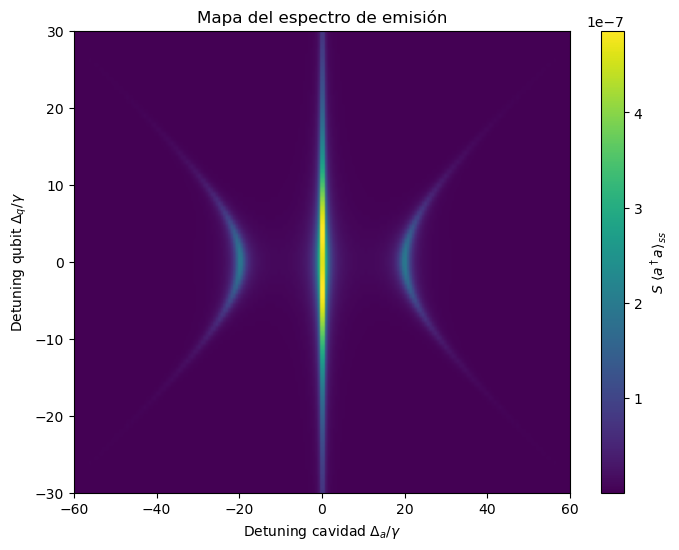

: 

In [ ]:
# ------------------------
# Gráfica tipo mapa
# ------------------------

plt.figure(figsize=(8,6))

plt.imshow(
    S_map,
    extent=[Delta_a_list[0], Delta_a_list[-1],
            Delta_q_list[0], Delta_q_list[-1]],
    aspect='auto',
    origin='lower'
)

plt.xlabel("Detuning cavidad $\\Delta_a/\\gamma$")
plt.ylabel("Detuning qubit $\\Delta_q/\\gamma$")
plt.title("Mapa del espectro de emisión")
plt.ylim(-30,30)
plt.colorbar(label=r"$S\ \langle a^\dagger a \rangle_{ss}$")

plt.show()